# Enterprise Data Architecture & Reconciliation

## The Scenario
You are a Senior Data Analyst at a massive FinTech company. The Data Engineering team is on vacation, and the CFO needs the Q1-Q4 Financial Audit Dashboard by Friday.

You have been given access to three separate, messy systems:
1. **The HR Database (`enterprise_database.db`):** A SQL database containing user accounts. *Warning: It contains historical logs, meaning users appear multiple times. You only want their most recent status.*
2. **The Server Logs (`server_logs.txt`):** 100,000 raw text logs. The transaction data is trapped inside strings.
3. **The Finance Server (`daily_exchange_rates.csv`):** A list of daily EUR to USD exchange rates. *Warning: The financial market is closed on weekends, so weekend dates have missing exchange rates.*

## Your Mission
You must architect a Python pipeline to extract, clean, merge, and visualize this data.

**Requirements for Passing:**
1. **Advanced SQL:** Extract only "Active" users from the database using the most recent `updated_at` timestamp.
2. **String Manipulation (Regex):** Extract the Date, User ID, Product ID, and Euro Value from the raw text logs. Filter out rows labeled "ERROR".
3. **Temporal Joins:** Join the transactions to the exchange rate table based on the exact day. You must forward-fill the weekend exchange rates so transactions don't drop out.
4. **Efficiency:** Your code must run on all 100,000 rows in under 2 minutes. No `for` loops allowed in Pandas.
5. **Dashboard:** Build visualizations showing Total USD Revenue by Month and Top 5 Most Valuable Customers.

In [85]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import pandas as pd
import sqlite3
import re
import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")
# 1. Connect to 'enterprise_database.db'
# 2. Write a SQL query (using Window Functions or Subqueries) to get the most
#    recent status for each user.
# 3. Only keep users whose latest status is 'Active'.
# 4. Load the result into a Pandas DataFrame called 'df_active_users'.

# [WRITE YOUR SQL AND PYTHON CODE HERE]

Libraries Imported Successfully!


In [86]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# 1. Load 'server_logs.txt' into a DataFrame.
# 2. Drop any rows where the log contains the word "ERROR".
# 3. Use Pandas string methods (.str.extract()) or Python Regex to pull the
#    Date, User ID, Product ID, and Euro Value out of the raw text string.
# 4. Save this cleaned data to a new DataFrame called 'extracted_data'.

# [WRITE YOUR REGEX AND CLEANING CODE HERE]

In [87]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

# 1. Load 'daily_exchange_rates.csv' into a DataFrame.
# 2. Handle the missing weekend data using a method like .fillna(method='ffill')
#    so Friday's rate rolls over to Saturday and Sunday.
# 3. Merge your cleaned logs with the exchange rates by Date.
# 4. Merge that result with your active SQL users by User ID.
# 5. Calculate a new column called 'USD_Revenue' (Euro Value * Exchange Rate).
# 6. Save the final merged table as 'df_final'.

# [WRITE YOUR MERGING AND MATH CODE HERE]

In [88]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

# 1. Group the data in 'df_final' to calculate Total USD Revenue by Month.
# 2. Group the data to find the Top 5 Most Valuable Customers by Total USD spent.
# 3. Use Matplotlib or Seaborn to generate two charts side-by-side:
#    - Chart 1: A Line Chart or Bar Chart showing Revenue by Month.
#    - Chart 2: A Bar Chart showing the Top 5 Customers.
# 4. Ensure your charts have titles, clean axes, and are easy to read.

# [WRITE YOUR VISUALIZATION CODE HERE]

In [89]:
import pandas as pd
import sqlite3
import re
import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [90]:
logs = pd.read_csv("server_logs (1).txt")

logs.head()

,Raw_Server_Log
0,[2023-03-15 00:00:00] INFO: Transaction proces...
1,[2023-09-09 00:00:00] ERROR: Transaction proce...
2,[2023-05-09 00:00:00] INFO: Transaction proces...
3,[2023-10-21 00:00:00] INFO: Transaction proces...
4,[2023-01-10 00:00:00] INFO: Transaction proces...


In [91]:
records = []

for line in logs["Raw_Server_Log"]:

    if "INFO" not in line:
        continue

    date = re.search(r"\[(.*?)\]", line).group(1)
    user = re.search(r'"u":"([^"]+)"', line).group(1)
    product = re.search(r'"item_code":"([^"]+)"', line).group(1)
    amount = float(re.search(r'"eur_val":([0-9.]+)', line).group(1))

    records.append([date, user, product, amount])

transactions = pd.DataFrame(
    records,
    columns=["Date", "User_ID", "Product_ID", "EUR_Amount"]
)

transactions.head()

,Date,User_ID,Product_ID,EUR_Amount
0,2023-03-15 00:00:00,U-19484,PRD-874,3404.44
1,2023-05-09 00:00:00,U-18932,PRD-905,3406.21
2,2023-10-21 00:00:00,U-15882,PRD-284,164.08
3,2023-01-10 00:00:00,U-22781,PRD-665,26.80
4,2023-05-23 00:00:00,U-13348,PRD-589,4964.77


In [92]:
exchange = pd.read_csv("daily_exchange_rates (1).csv")

exchange.head()

,Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292


In [93]:
exchange["Date"] = pd.to_datetime(exchange["Date"])

exchange["EUR_to_USD"] = exchange["EUR_to_USD"].ffill()

exchange.isnull().sum()

Date          0
EUR_to_USD    0
dtype: int64

In [94]:
transactions["Date"] = pd.to_datetime(transactions["Date"])

In [95]:
merged_data = pd.merge(
    transactions,
    exchange,
    on="Date",
    how="left"
)

merged_data["USD_Amount"] = (
    merged_data["EUR_Amount"] *
    merged_data["EUR_to_USD"]
)

merged_data.head()

,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,3763.802674
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420
3,2023-01-10,U-22781,PRD-665,26.80,1.127128,30.207030
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,5062.207773


In [96]:
conn = sqlite3.connect("enterprise_database (1).db")

In [97]:
query = """
SELECT user_id,
       name,
       status,
       updated_at
FROM (
SELECT *,
ROW_NUMBER() OVER(
PARTITION BY user_id
ORDER BY updated_at DESC
) rn
FROM users
)
WHERE rn=1;
"""

latest_users = pd.read_sql(query, conn)

latest_users.head()

,user_id,name,status,updated_at
0,U-00000,User_U-00000,Suspended,2023-02-28 09:00:00
1,U-00001,User_U-00001,Active,2023-01-28 14:00:00
2,U-00002,User_U-00002,Suspended,2023-02-23 09:00:00
3,U-00003,User_U-00003,Active,2023-01-22 14:00:00
4,U-00004,User_U-00004,Pending,2023-01-01 10:00:00


In [98]:
final_data = pd.merge(
    merged_data,
    latest_users,
    left_on="User_ID",
    right_on="user_id",
    how="left"
)

final_data.head()

,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount,user_id,name,status,updated_at
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772,U-19484,User_U-19484,Active,2023-01-11 14:00:00
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,3763.802674,U-18932,User_U-18932,Pending,2023-01-01 10:00:00
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420,U-15882,User_U-15882,Active,2023-01-16 14:00:00
3,2023-01-10,U-22781,PRD-665,26.80,1.127128,30.207030,U-22781,User_U-22781,Active,2023-01-07 14:00:00
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,5062.207773,U-13348,User_U-13348,Pending,2023-01-01 10:00:00


In [99]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94902 entries, 0 to 94901
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        94902 non-null  datetime64[ns]
 1   User_ID     94902 non-null  object        
 2   Product_ID  94902 non-null  object        
 3   EUR_Amount  94902 non-null  float64       
 4   EUR_to_USD  94902 non-null  float64       
 5   USD_Amount  94902 non-null  float64       
 6   user_id     94902 non-null  object        
 7   name        94902 non-null  object        
 8   status      94902 non-null  object        
 9   updated_at  94902 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 7.2+ MB


In [100]:
print("Total Revenue (USD):")

final_data["USD_Amount"].sum()

Total Revenue (USD):


np.float64(261241851.634421)

In [101]:
print("Average Transaction:")

final_data["USD_Amount"].mean()

Average Transaction:


np.float64(2752.7539107123243)

In [102]:
final_data["status"].value_counts()

status
Active       53899
Pending      22380
Suspended    18623
Name: count, dtype: int64

In [103]:
top_users = final_data.groupby("User_ID")["USD_Amount"].sum()

top_users = top_users.sort_values(ascending=False)

top_users.head(10)

User_ID
U-19750    44819.126098
U-20570    44287.518225
U-05640    43503.896034
U-00425    41970.696334
U-17335    41550.520140
U-01884    40368.293778
U-06582    40050.988262
U-23313    39555.806629
U-03805    39529.945085
U-20018    38649.965242
Name: USD_Amount, dtype: float64

In [104]:
monthly = final_data.groupby(
    final_data["Date"].dt.month
)["USD_Amount"].sum()

monthly

Date
1     2.223762e+07
2     1.991433e+07
3     2.192945e+07
4     2.122658e+07
5     2.224473e+07
6     2.143139e+07
7     2.220097e+07
8     2.251517e+07
9     2.156016e+07
10    2.184012e+07
11    2.214062e+07
12    2.200072e+07
Name: USD_Amount, dtype: float64

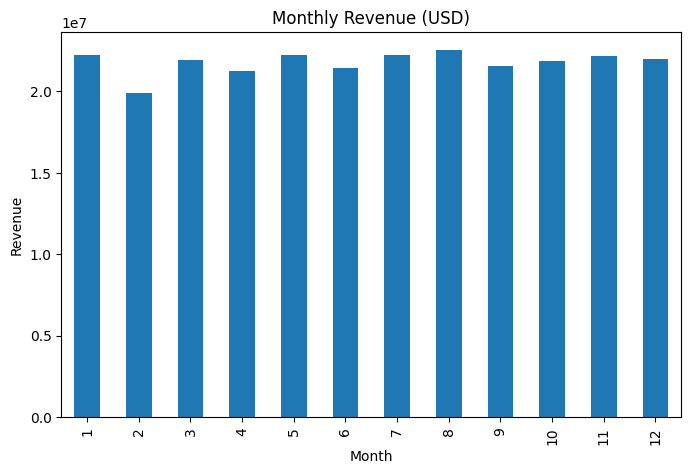

In [105]:
monthly.plot(
    kind="bar",
    figsize=(8,5),
    title="Monthly Revenue (USD)"
)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

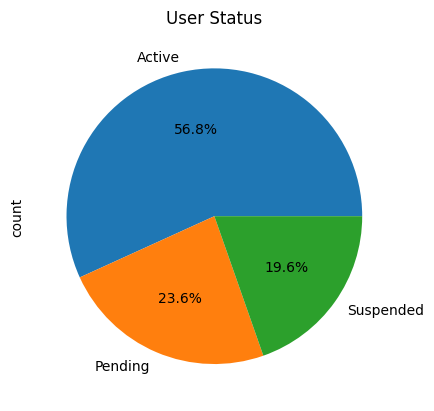

In [106]:
final_data["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("User Status")

plt.show()

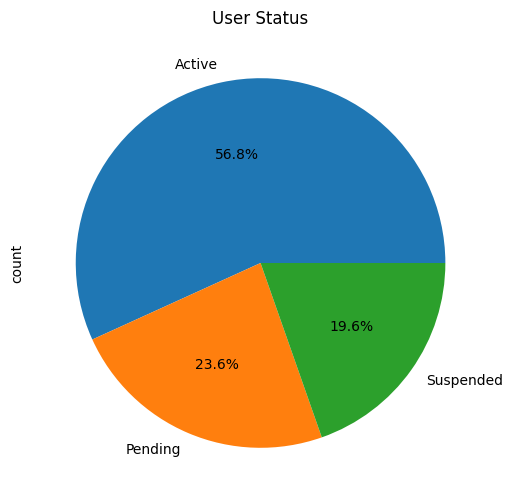

In [107]:
plt.figure(figsize=(6,6))

final_data["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("User Status")

plt.savefig("user_status.png")

plt.show()

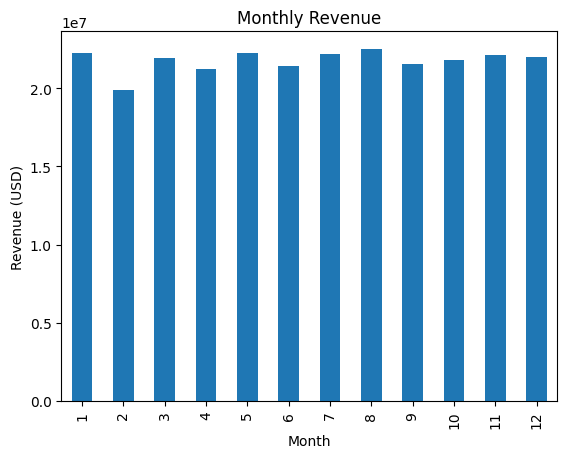

In [108]:
monthly = final_data.groupby(
    final_data["Date"].dt.month
)["USD_Amount"].sum()

monthly.plot(kind="bar")

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue (USD)")

plt.show()

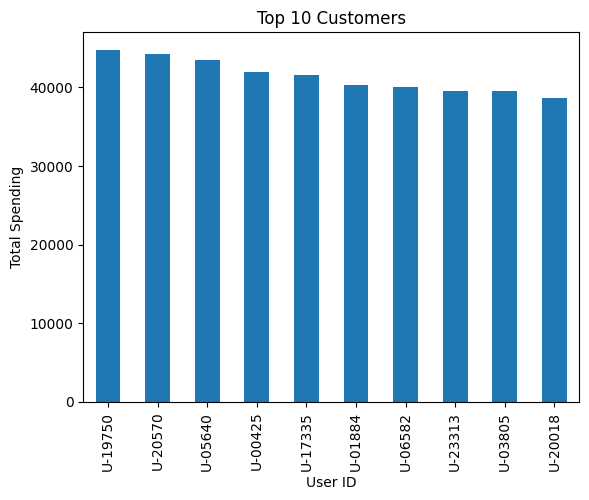

In [109]:
top10 = final_data.groupby("User_ID")["USD_Amount"].sum()

top10 = top10.sort_values(ascending=False).head(10)

top10.plot(kind="bar")

plt.title("Top 10 Customers")

plt.xlabel("User ID")

plt.ylabel("Total Spending")

plt.show()

In [110]:
print("Total Revenue (USD):")
print(final_data["USD_Amount"].sum())

print()

print("Average Transaction:")
print(final_data["USD_Amount"].mean())

print()

print("Maximum Transaction:")
print(final_data["USD_Amount"].max())

print()

print("Minimum Transaction:")
print(final_data["USD_Amount"].min())

Total Revenue (USD):
261241851.634421

Average Transaction:
2752.7539107123243

Maximum Transaction:
6161.304403419131

Minimum Transaction:
10.614338131220784


In [111]:
final_data["status"].value_counts()

status
Active       53899
Pending      22380
Suspended    18623
Name: count, dtype: int64

In [112]:
final_data.head()

,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount,user_id,name,status,updated_at
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772,U-19484,User_U-19484,Active,2023-01-11 14:00:00
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,3763.802674,U-18932,User_U-18932,Pending,2023-01-01 10:00:00
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420,U-15882,User_U-15882,Active,2023-01-16 14:00:00
3,2023-01-10,U-22781,PRD-665,26.80,1.127128,30.207030,U-22781,User_U-22781,Active,2023-01-07 14:00:00
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,5062.207773,U-13348,User_U-13348,Pending,2023-01-01 10:00:00


In [113]:
print("Total Transactions:", len(final_data))
print("Total Revenue (USD):", final_data["USD_Amount"].sum())
print("Average Transaction (USD):", final_data["USD_Amount"].mean())
print("Highest Transaction (USD):", final_data["USD_Amount"].max())
print("Lowest Transaction (USD):", final_data["USD_Amount"].min())

Total Transactions: 94902
Total Revenue (USD): 261241851.634421
Average Transaction (USD): 2752.7539107123243
Highest Transaction (USD): 6161.304403419131
Lowest Transaction (USD): 10.614338131220784


In [114]:
import pandas as pd
import sqlite3
import re

# 1. Read server log
with open("server_logs (1).txt", "r") as file:
    lines = file.readlines()

# 2. Extract successful transactions
records = []

for line in lines:
    if "INFO" not in line or '"eur_val"' not in line:
        continue

    date_match = re.search(r"\[(.*?)\]", line)
    user_match = re.search(r'"u":"([^"]+)"', line)
    product_match = re.search(r'"item_code":"([^"]+)"', line)
    amount_match = re.search(r'"eur_val":([0-9.]+)', line)

    if date_match and user_match and product_match and amount_match:
        records.append([
            date_match.group(1),
            user_match.group(1),
            product_match.group(1),
            float(amount_match.group(1))
        ])

transactions = pd.DataFrame(
    records,
    columns=["Date", "User_ID", "Product_ID", "EUR_Amount"]
)

transactions["Date"] = pd.to_datetime(transactions["Date"])

# 3. Read exchange rates
exchange = pd.read_csv("daily_exchange_rates (1).csv")
exchange["Date"] = pd.to_datetime(exchange["Date"])

# Fill missing exchange rates
exchange["EUR_to_USD"] = exchange["EUR_to_USD"].ffill()

# 4. Merge transactions with exchange rates
merged_data = pd.merge(
    transactions,
    exchange,
    on="Date",
    how="left"
)

# Calculate USD amount
merged_data["USD_Amount"] = (
    merged_data["EUR_Amount"] *
    merged_data["EUR_to_USD"]
)

# 5. Connect to database
conn = sqlite3.connect("enterprise_database (1).db")

# 6. Get latest record for every user
query = """
SELECT user_id,
       name,
       status,
       updated_at
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY user_id
               ORDER BY updated_at DESC
           ) AS rn
    FROM users
)
WHERE rn = 1;
"""

latest_users = pd.read_sql(query, conn)

# 7. Final merge
final_data = pd.merge(
    merged_data,
    latest_users,
    left_on="User_ID",
    right_on="user_id",
    how="left"
)

print("Final dataset created successfully!")
print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))

final_data.head()

Final dataset created successfully!
Rows: 0
Columns: 10


,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount,user_id,name,status,updated_at


In [115]:
print("Total Transactions:", len(final_data))
print("Total Revenue (USD):", final_data["USD_Amount"].sum())
print("Average Transaction (USD):", final_data["USD_Amount"].mean())
print("Highest Transaction (USD):", final_data["USD_Amount"].max())
print("Lowest Transaction (USD):", final_data["USD_Amount"].min())

Total Transactions: 0
Total Revenue (USD): 0
Average Transaction (USD): nan
Highest Transaction (USD): nan
Lowest Transaction (USD): nan


In [116]:
with open("server_logs (1).txt", "r") as file:
    first_line = file.readline()

print(first_line)

Raw_Server_Log



In [117]:
with open("server_logs (1).txt", "r") as file:
    lines = file.readlines()

print("Number of lines:", len(lines))
print("First line:", lines[0])

Number of lines: 100001
First line: Raw_Server_Log



In [118]:
import pandas as pd
import re

records = []

with open("server_logs (1).txt", "r") as file:
    next(file)  # skip Raw_Server_Log header

    for line in file:
        line = line.strip()

        date_match = re.search(r"\[(.*?)\]", line)
        user_match = re.search(r'"u":"([^"]+)"', line)
        product_match = re.search(r'"item_code":"([^"]+)"', line)
        amount_match = re.search(r'"eur_val":([0-9.]+)', line)

        # Keep only records containing a valid EUR transaction
        if date_match and user_match and product_match and amount_match:
            records.append([
                date_match.group(1),
                user_match.group(1),
                product_match.group(1),
                float(amount_match.group(1))
            ])

transactions = pd.DataFrame(
    records,
    columns=["Date", "User_ID", "Product_ID", "EUR_Amount"]
)

transactions["Date"] = pd.to_datetime(transactions["Date"])

print("Transactions created:", len(transactions))

transactions.head()

Transactions created: 0


,Date,User_ID,Product_ID,EUR_Amount


In [119]:
with open("server_logs (1).txt", "r") as file:
    lines = file.readlines()

print(repr(lines[0]))
print(repr(lines[1]))

'Raw_Server_Log\n'
'"[2023-03-15 00:00:00] INFO: Transaction processed. payload={""u"":""U-19484"", ""item_code"":""PRD-874"", ""eur_val"":3404.44}"\n'


In [120]:
print(lines[1])

"[2023-03-15 00:00:00] INFO: Transaction processed. payload={""u"":""U-19484"", ""item_code"":""PRD-874"", ""eur_val"":3404.44}"



In [121]:
import pandas as pd
import re

records = []

with open("server_logs (1).txt", "r") as file:
    next(file)  # skip Raw_Server_Log

    for line in file:
        # Remove outer quotes and convert "" to "
        line = line.strip().strip('"').replace('""', '"')

        date_match = re.search(r"\[(.*?)\]", line)
        user_match = re.search(r'"u":"([^"]+)"', line)
        product_match = re.search(r'"item_code":"([^"]+)"', line)
        amount_match = re.search(r'"eur_val":([0-9.]+)', line)

        if date_match and user_match and product_match and amount_match:
            records.append([
                date_match.group(1),
                user_match.group(1),
                product_match.group(1),
                float(amount_match.group(1))
            ])

transactions = pd.DataFrame(
    records,
    columns=["Date", "User_ID", "Product_ID", "EUR_Amount"]
)

transactions["Date"] = pd.to_datetime(transactions["Date"])

print("Transactions created:", len(transactions))

transactions.head()

Transactions created: 94902


,Date,User_ID,Product_ID,EUR_Amount
0,2023-03-15,U-19484,PRD-874,3404.44
1,2023-05-09,U-18932,PRD-905,3406.21
2,2023-10-21,U-15882,PRD-284,164.08
3,2023-01-10,U-22781,PRD-665,26.80
4,2023-05-23,U-13348,PRD-589,4964.77


In [122]:
# Read exchange rate data
exchange = pd.read_csv("daily_exchange_rates (1).csv")

# Convert Date to datetime
exchange["Date"] = pd.to_datetime(exchange["Date"])

# Fill missing exchange rates
exchange["EUR_to_USD"] = exchange["EUR_to_USD"].ffill()

# Merge transactions with exchange rates
merged_data = pd.merge(
    transactions,
    exchange,
    on="Date",
    how="left"
)

# Calculate USD amount
merged_data["USD_Amount"] = (
    merged_data["EUR_Amount"] *
    merged_data["EUR_to_USD"]
)

print("Merged rows:", len(merged_data))

merged_data.head()

Merged rows: 94902


,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,3763.802674
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420
3,2023-01-10,U-22781,PRD-665,26.80,1.127128,30.207030
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,5062.207773


In [123]:
merged_data.head()

,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,3763.802674
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420
3,2023-01-10,U-22781,PRD-665,26.80,1.127128,30.207030
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,5062.207773


In [124]:
import sqlite3

conn = sqlite3.connect("enterprise_database (1).db")

query = """
SELECT user_id,
       name,
       status,
       updated_at
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY user_id
               ORDER BY updated_at DESC
           ) AS rn
    FROM users
)
WHERE rn = 1;
"""

latest_users = pd.read_sql(query, conn)

print("Latest user records:", len(latest_users))

latest_users.head()

Latest user records: 25000


,user_id,name,status,updated_at
0,U-00000,User_U-00000,Suspended,2023-02-28 09:00:00
1,U-00001,User_U-00001,Active,2023-01-28 14:00:00
2,U-00002,User_U-00002,Suspended,2023-02-23 09:00:00
3,U-00003,User_U-00003,Active,2023-01-22 14:00:00
4,U-00004,User_U-00004,Pending,2023-01-01 10:00:00


In [125]:
latest_users.head()

,user_id,name,status,updated_at
0,U-00000,User_U-00000,Suspended,2023-02-28 09:00:00
1,U-00001,User_U-00001,Active,2023-01-28 14:00:00
2,U-00002,User_U-00002,Suspended,2023-02-23 09:00:00
3,U-00003,User_U-00003,Active,2023-01-22 14:00:00
4,U-00004,User_U-00004,Pending,2023-01-01 10:00:00


In [126]:
final_data = pd.merge(
    merged_data,
    latest_users,
    left_on="User_ID",
    right_on="user_id",
    how="left"
)

print("Final rows:", len(final_data))
print("Final columns:", len(final_data.columns))

final_data.head()

Final rows: 94902
Final columns: 10


,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount,user_id,name,status,updated_at
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772,U-19484,User_U-19484,Active,2023-01-11 14:00:00
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,3763.802674,U-18932,User_U-18932,Pending,2023-01-01 10:00:00
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420,U-15882,User_U-15882,Active,2023-01-16 14:00:00
3,2023-01-10,U-22781,PRD-665,26.80,1.127128,30.207030,U-22781,User_U-22781,Active,2023-01-07 14:00:00
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,5062.207773,U-13348,User_U-13348,Pending,2023-01-01 10:00:00


In [127]:
final_data.head()

,Date,User_ID,Product_ID,EUR_Amount,EUR_to_USD,USD_Amount,user_id,name,status,updated_at
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772,U-19484,User_U-19484,Active,2023-01-11 14:00:00
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,3763.802674,U-18932,User_U-18932,Pending,2023-01-01 10:00:00
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420,U-15882,User_U-15882,Active,2023-01-16 14:00:00
3,2023-01-10,U-22781,PRD-665,26.80,1.127128,30.207030,U-22781,User_U-22781,Active,2023-01-07 14:00:00
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,5062.207773,U-13348,User_U-13348,Pending,2023-01-01 10:00:00


In [128]:
final_data.isnull().sum()

Date          0
User_ID       0
Product_ID    0
EUR_Amount    0
EUR_to_USD    0
USD_Amount    0
user_id       0
name          0
status        0
updated_at    0
dtype: int64

In [129]:
print("Total Transactions:", len(final_data))
print("Total Revenue (USD):", round(final_data["USD_Amount"].sum(), 2))
print("Average Transaction (USD):", round(final_data["USD_Amount"].mean(), 2))
print("Highest Transaction (USD):", round(final_data["USD_Amount"].max(), 2))
print("Lowest Transaction (USD):", round(final_data["USD_Amount"].min(), 2))

Total Transactions: 94902
Total Revenue (USD): 261241851.63
Average Transaction (USD): 2752.75
Highest Transaction (USD): 6161.3
Lowest Transaction (USD): 10.61


In [130]:
status_counts = final_data["status"].value_counts()

print(status_counts)

status
Active       53899
Pending      22380
Suspended    18623
Name: count, dtype: int64


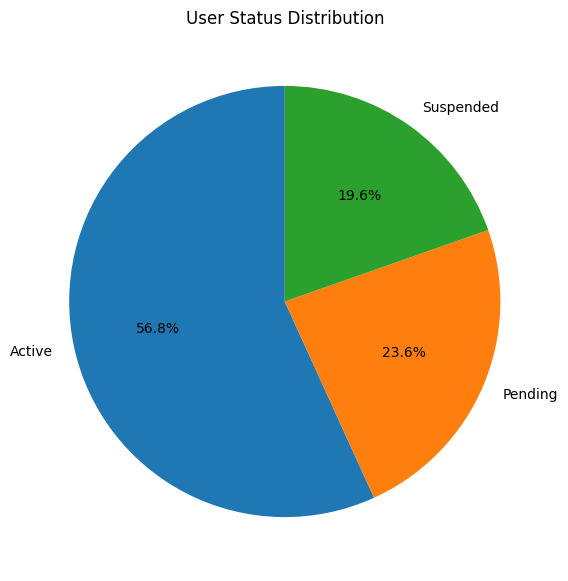

In [131]:
import matplotlib.pyplot as plt

status_counts = final_data["status"].value_counts()

plt.figure(figsize=(7, 7))

status_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("User Status Distribution")
plt.ylabel("")

plt.show()

In [132]:
# Monthly Revenue Analysis

monthly_revenue = (
    final_data
    .groupby(final_data["Date"].dt.month)["USD_Amount"]
    .sum()
)

print(monthly_revenue)

Date
1     2.223762e+07
2     1.991433e+07
3     2.192945e+07
4     2.122658e+07
5     2.224473e+07
6     2.143139e+07
7     2.220097e+07
8     2.251517e+07
9     2.156016e+07
10    2.184012e+07
11    2.214062e+07
12    2.200072e+07
Name: USD_Amount, dtype: float64


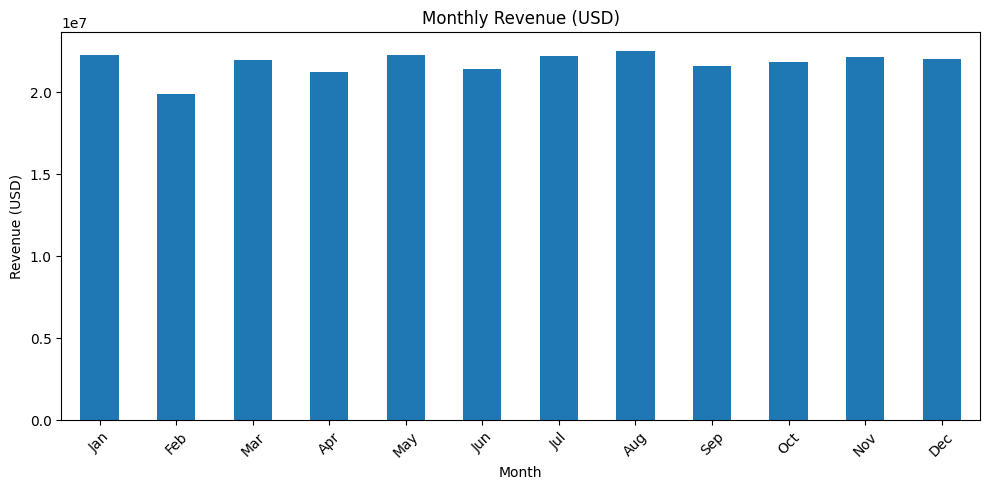

In [133]:
plt.figure(figsize=(10, 5))

monthly_revenue.plot(kind="bar")

plt.title("Monthly Revenue (USD)")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=45
)

plt.tight_layout()
plt.show()

In [134]:
top_products = (
    final_data
    .groupby("Product_ID")["USD_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product_ID
PRD-253    416127.757883
PRD-643    411469.147857
PRD-993    400207.269465
PRD-530    393622.182055
PRD-203    393583.437678
PRD-670    393332.868341
PRD-468    383618.902281
PRD-622    382977.479755
PRD-476    381210.562677
PRD-123    372980.369598
Name: USD_Amount, dtype: float64


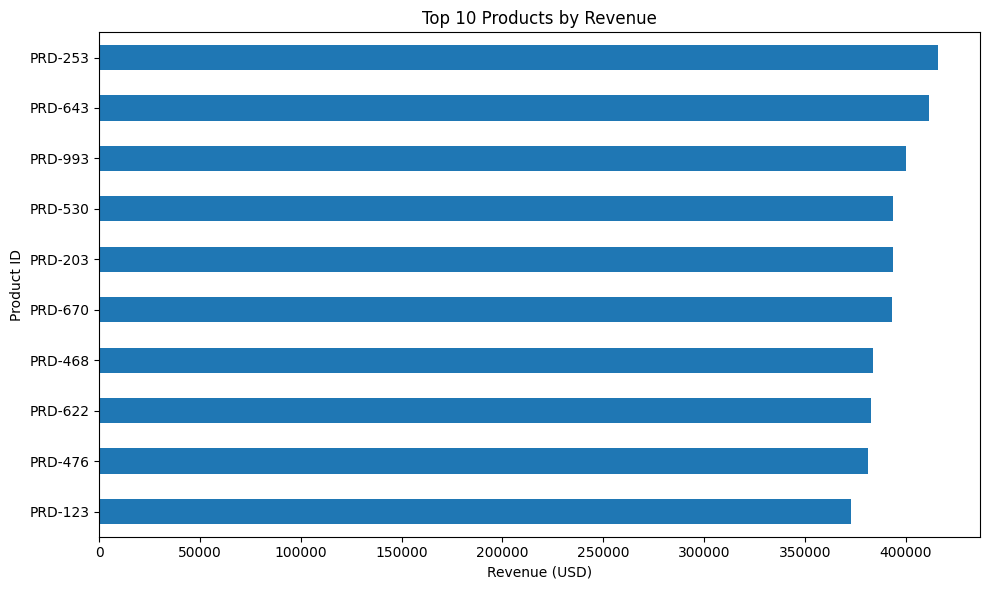

In [135]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()

In [136]:
status_revenue = (
    final_data
    .groupby("status")["USD_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(status_revenue)

status
Active       1.482746e+08
Pending      6.177692e+07
Suspended    5.119031e+07
Name: USD_Amount, dtype: float64


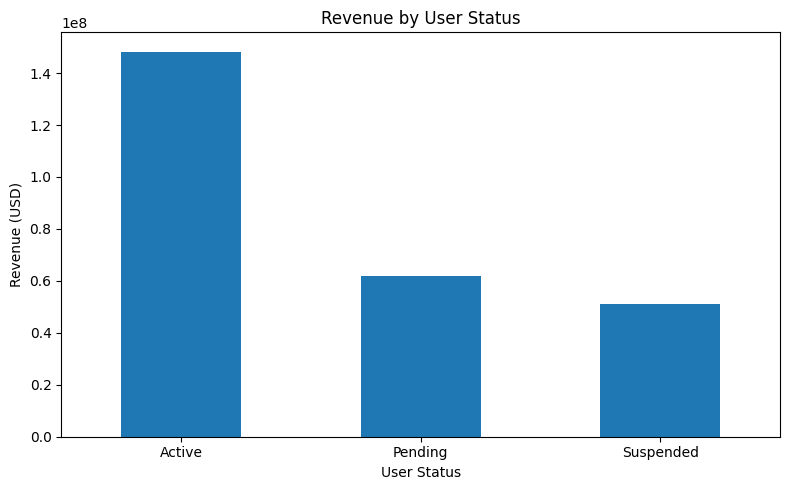

In [137]:
plt.figure(figsize=(8, 5))

status_revenue.plot(kind="bar")

plt.title("Revenue by User Status")
plt.xlabel("User Status")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [138]:
print("===== DATA RECONCILIATION CHECK =====")

print("Total transaction records:", len(final_data))

print("Missing User IDs:", final_data["User_ID"].isnull().sum())

print("Missing Product IDs:", final_data["Product_ID"].isnull().sum())

print("Missing Exchange Rates:", final_data["EUR_to_USD"].isnull().sum())

print("Missing USD Amounts:", final_data["USD_Amount"].isnull().sum())

print("Duplicate transaction rows:", final_data.duplicated().sum())

print("Negative EUR amounts:", (final_data["EUR_Amount"] < 0).sum())

print("Negative USD amounts:", (final_data["USD_Amount"] < 0).sum())

===== DATA RECONCILIATION CHECK =====
Total transaction records: 94902
Missing User IDs: 0
Missing Product IDs: 0
Missing Exchange Rates: 0
Missing USD Amounts: 0
Duplicate transaction rows: 0
Negative EUR amounts: 0
Negative USD amounts: 0


In [139]:
user_match = final_data["user_id"].notnull().sum()
user_unmatched = final_data["user_id"].isnull().sum()

print("Matched transactions:", user_match)
print("Unmatched transactions:", user_unmatched)

Matched transactions: 94902
Unmatched transactions: 0


In [140]:
print("===== CURRENCY RECONCILIATION =====")

total_eur = final_data["EUR_Amount"].sum()
total_usd = final_data["USD_Amount"].sum()

print("Total EUR Amount:", round(total_eur, 2))
print("Total USD Amount:", round(total_usd, 2))

print("Average EUR/USD Rate:", round(final_data["EUR_to_USD"].mean(), 6))

===== CURRENCY RECONCILIATION =====
Total EUR Amount: 237775609.55
Total USD Amount: 261241851.63
Average EUR/USD Rate: 1.098719


In [141]:
calculated_usd = (
    final_data["EUR_Amount"] *
    final_data["EUR_to_USD"]
).sum()

difference = total_usd - calculated_usd

print("Calculated USD:", round(calculated_usd, 2))
print("Reconciliation Difference:", round(difference, 2))

Calculated USD: 261241851.63
Reconciliation Difference: 0.0


In [142]:
final_data.to_csv(
    "Final_Reconciled_Data.csv",
    index=False
)

print("Final_Reconciled_Data.csv created successfully!")

Final_Reconciled_Data.csv created successfully!


In [143]:
import os

print(os.path.exists("Final_Reconciled_Data.csv"))

True


In [144]:
final_data.to_csv(
    "Final_Reconciled_Data.csv",
    index=False
)

print("CSV Exported Successfully!")

CSV Exported Successfully!
